[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter2_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 2: ARMA models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- AR($p$) and MA($q$): stationarity, invertibility, characteristic roots, ACF and PACF.
- ARMA($p,q$): psi weights (impulse responses), identification patterns.
- Estimation (Yule–Walker, conditional least squares, maximum likelihood), AIC and BIC, residual diagnostics.
- Forecasts and intervals; the Box–Jenkins method on Romanian GDP growth; inflation, BET, EUR/RON, sunspots.
- References: Huang and Petukhina (2022), *Applied Time Series Analysis and Forecasting with Python*, Ch. 3–4; Hyndman and Athanasopoulos, *Forecasting: Principles and Practice* (3rd ed.), Ch. 9; Brockwell and Davis (2016), Ch. 3 and 5.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_2'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions used in the whole notebook

- ARMA($p,q$): $\phi(L)(X_t - \mu) = \theta(L)\varepsilon_t$ with $\phi(z) = 1 - \phi_1 z - \dots - \phi_p z^p$, $\theta(z) = 1 + \theta_1 z + \dots + \theta_q z^q$ (the sign convention of statsmodels).
- `fit_arma(x, p, q)`: exact Gaussian maximum likelihood (`statsmodels` `ARIMA`); `const` is the mean $\mu$.
- `ljung_box(x, m, df)`: Ljung–Box $Q^*(m)$ with $df$ degrees of freedom ($m - p - q$ for residuals).
- `psi_weights`, `theoretical_acf`, `theoretical_pacf`, `inverse_roots`: the theory of the slides.

In [5]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.regression.linear_model import yule_walker
SEED = 2026
GDP_NSA = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
GDP_SCA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
GDP_START = '2000-01-01'
INFL_START = '2005-01-01'
BAND_COL = st.IDAred
MODELS = {'AR(2)': ([1.0, -0.6], []), 'MA(2)': ([], [0.6, 0.3]), 'ARMA(1,1)': ([0.7], [0.4])}
HERE = "."


def ro_gdp_growth(kind='yoy', start=GDP_START):
    """Romanian real GDP growth in %: 'yoy' = 100 (ln Y_t - ln Y_{t-4}) of the unadjusted series,
    'qoq' = 100 (ln Y_t - ln Y_{t-1}) of the seasonally adjusted series."""
    if kind == 'yoy':
        y = 100 * np.log(read_eurostat(*GDP_NSA)).diff(4)
    else:
        y = 100 * np.log(read_eurostat(*GDP_SCA)).diff()
    y = y.dropna().loc[start:]
    y.index.freq = None
    return y.rename(f'gdp_{kind}')


def ro_inflation(start=INFL_START):
    """Romanian 12-month HICP inflation in %: 100 (ln P_t - ln P_{t-12})."""
    p = read_eurostat(*HICP)
    return (100 * np.log(p).diff(12)).dropna().loc[start:].rename('inflation')


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T (Chapter 1)."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    """Sample PACF phi_hh, h = 1..nlags (Durbin-Levinson on the sample ACF)."""
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=10, df=None):
    """Ljung-Box Q*(m) with its p-value from chi2(df); df = m by default, m - p - q for ARMA residuals."""
    x = np.asarray(x, float)
    T = len(x)
    r = sample_acf(x, m)
    q = T * (T + 2) * np.sum(r ** 2 / (T - np.arange(1, m + 1)))
    df = m if df is None else df
    return {'lb': float(q), 'df': int(df), 'lb_p': float(stats.chi2.sf(q, df))}


def acf_bars(ax, r, T, color=st.MainBlue, theory=None, label='sample', band=True, theory_label='theoretical'):
    """Bars at lags 1..len(r), the +-1.96/sqrt(T) band and optional theoretical values (dots)."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if theory is not None:
        ax.plot(lags, theory, 'o', ms=4, color=st.Orange, label=theory_label)
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def simulate_arma(phi=(), theta=(), n=500, sigma=1.0, mu=0.0, burn=500, rng=None):
    """X_t - mu = sum phi_i (X_{t-i} - mu) + e_t + sum theta_j e_{t-j}, e_t i.i.d. N(0, sigma^2), after a burn-in."""
    rng = rng if rng is not None else np.random.default_rng(SEED)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        x[t] = e[t] + sum(phi[i] * x[t - 1 - i] for i in range(p) if t - 1 - i >= 0) \
            + sum(theta[j] * e[t - 1 - j] for j in range(q) if t - 1 - j >= 0)
    return mu + x[burn:]


def arma_process(phi=(), theta=()):
    """statsmodels ArmaProcess for X_t = phi_1 X_{t-1} + ... + e_t + theta_1 e_{t-1} + ... (signs as in the slides)."""
    return ArmaProcess(np.r_[1, -np.asarray(phi, float)], np.r_[1, np.asarray(theta, float)])


def theoretical_acf(phi=(), theta=(), nlags=20):
    return arma_process(phi, theta).acf(nlags + 1)[1:]


def theoretical_pacf(phi=(), theta=(), nlags=20):
    return arma_process(phi, theta).pacf(nlags + 1)[1:]


def psi_weights(phi=(), theta=(), n=20):
    """psi_0, ..., psi_{n-1} of the causal representation X_t = sum psi_j e_{t-j}:
    psi_j = theta_j + sum_{i=1}^{min(j,p)} phi_i psi_{j-i}, psi_0 = 1."""
    p, q = len(phi), len(theta)
    psi = np.zeros(n)
    psi[0] = 1.0
    for j in range(1, n):
        psi[j] = (theta[j - 1] if j <= q else 0.0) + sum(phi[i] * psi[j - 1 - i] for i in range(min(j, p)))
    return psi


def inverse_roots(phi):
    """Inverse roots of 1 - phi_1 z - ... - phi_p z^p (stationary iff all have modulus < 1)."""
    roots = np.roots(np.r_[-np.asarray(phi, float)[::-1], 1.0])
    return 1 / roots


def fit_arma(x, p, q, trend='c'):
    """Gaussian maximum likelihood (statsmodels state-space ARIMA)."""
    return ARIMA(np.asarray(x, float), order=(p, 0, q), trend=trend).fit()


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()

## 1. AR(1) and AR(2)

- AR(1) with three values of $\phi$; the AR(2) stationarity triangle, inverse roots and damped waves.

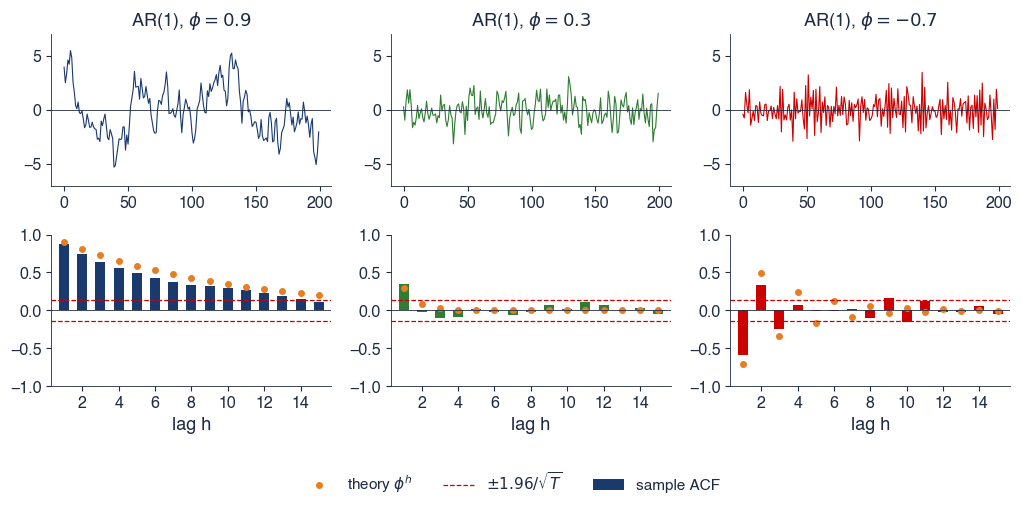

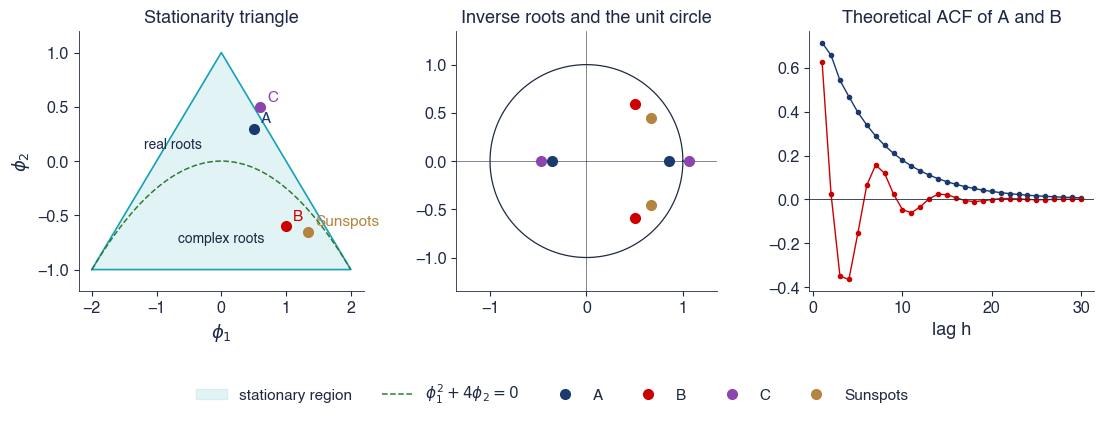

{'A': {'phi': [0.5, 0.3],
  'inv_roots_mod': [0.35207972893961476, 0.8520797289396147],
  'roots': [[-2.8402657631320496, 0.0], [1.1735990964653826, 0.0]],
  'stationary': True,
  'rho1': 0.7142857142857143,
  'rho2': 0.6571428571428571},
 'B': {'phi': [1.0, -0.6],
  'inv_roots_mod': [0.7745966692414832, 0.7745966692414832],
  'roots': [[0.8333333333333335, 0.9860132971832695],
   [0.8333333333333335, -0.9860132971832695]],
  'stationary': True,
  'period': 7.229346213269922,
  'damp': 0.7745966692414834},
 'C': {'phi': [0.6, 0.5],
  'inv_roots_mod': [0.46811457478686086, 1.0681145747868608],
  'roots': [[-2.1362291495737216, 0.0], [0.9362291495737217, 0.0]],
  'stationary': False},
 'Sunspots': {'phi': [1.336, -0.65],
  'inv_roots_mod': [0.806225774829855, 0.806225774829855],
  'roots': [[1.0276923076923077, 0.6944854636143204],
   [1.0276923076923077, -0.6944854636143204]],
  'stationary': True}}

In [6]:
def fig_ar1(n=200, nlags=15, save_it=True):
    """AR(1) paths and sample/theoretical ACF for phi = 0.9, 0.3 and -0.7 (same shocks)."""
    phis = [0.9, 0.3, -0.7]
    cols = [st.MainBlue, st.Forest, st.IDAred]
    rng = np.random.default_rng(SEED)
    e = rng.normal(size=n + 300)
    fig, ax = plt.subplots(2, 3, figsize=(10.4, 4.6))
    out = {}
    for j, (ph, c) in enumerate(zip(phis, cols)):
        x = np.zeros(n + 300)
        for t in range(1, n + 300):
            x[t] = ph * x[t - 1] + e[t]
        x = x[300:]
        ax[0, j].plot(x, color=c, lw=0.8)
        ax[0, j].axhline(0, color=st.DarkText, lw=0.6)
        ax[0, j].set_title(rf'AR(1), $\phi = {ph}$')
        ax[0, j].set_ylim(-7, 7)
        r = sample_acf(x, nlags)
        acf_bars(ax[1, j], r, n, color=c, theory=ph ** np.arange(1, nlags + 1),
                 label='sample ACF' if j == 0 else '_nolegend_',
                 theory_label=r'theory $\phi^h$' if j == 0 else '_nolegend_')
        ax[1, j].set_ylim(-1, 1)
        ax[1, j].set_xlabel('lag h')
        if j:
            ax[1, j].get_lines()[1].set_label('_nolegend_')
        out[str(ph)] = {'r1': float(r[0]), 'r2': float(r[1]), 'r5': float(r[4]), 'var': float(x.var()),
                        'var_th': 1 / (1 - ph ** 2)}
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_ar1', save_it)
    return out


def fig_ar2(nlags=30, save_it=True, sun_phi=None):
    """The AR(2) stationarity triangle (real and complex roots), the inverse roots in the unit circle and the ACF
    of three AR(2) processes."""
    ex = {'A': (0.5, 0.3), 'B': (1.0, -0.6), 'C': (0.6, 0.5)}
    if sun_phi is not None:
        ex['Sunspots'] = tuple(sun_phi)
    cols = {'A': st.MainBlue, 'B': st.IDAred, 'C': st.Purple, 'Sunspots': st.Amber}
    fig, ax = plt.subplots(1, 3, figsize=(11.2, 3.7))
    f1 = np.linspace(-2, 2, 300)
    ax[0].fill([-2, 0, 2], [-1, 1, -1], color=st.Teal, alpha=0.12, label='stationary region')
    ax[0].plot([-2, 0, 2, -2], [-1, 1, -1, -1], color=st.Teal, lw=1.2, label='_nolegend_')
    ax[0].plot(f1, -f1 ** 2 / 4, color=st.Forest, ls='--', lw=1.1, label=r'$\phi_1^2 + 4\phi_2 = 0$')
    for k, (a, b) in ex.items():
        ax[0].plot(a, b, 'o', ms=7, color=cols[k], label=k)
        ax[0].annotate(k, (a, b), xytext=(5, 4), textcoords='offset points', color=cols[k], fontsize=11)
    ax[0].text(-0.75, 0.12, 'real roots', ha='center', fontsize=10, color=st.DarkText)
    ax[0].text(0, -0.75, 'complex roots', ha='center', fontsize=10, color=st.DarkText)
    ax[0].set_xlim(-2.2, 2.2)
    ax[0].set_ylim(-1.2, 1.2)
    ax[0].set_xlabel(r'$\phi_1$')
    ax[0].set_ylabel(r'$\phi_2$')
    ax[0].set_title('Stationarity triangle')
    th = np.linspace(0, 2 * np.pi, 400)
    ax[1].plot(np.cos(th), np.sin(th), color=st.DarkText, lw=0.9, label='_nolegend_')
    ax[1].axhline(0, color=st.DarkText, lw=0.4)
    ax[1].axvline(0, color=st.DarkText, lw=0.4)
    out = {}
    for k, ph in ex.items():
        ir = inverse_roots(ph)
        ax[1].plot(ir.real, ir.imag, 'o', ms=7, color=cols[k], label='_nolegend_')
        out[k] = {'phi': list(ph), 'inv_roots_mod': [float(abs(z)) for z in ir],
                  'roots': [[float(z.real), float(z.imag)] for z in 1 / ir], 'stationary': bool(np.all(abs(ir) < 1))}
    ax[1].set_aspect('equal')
    ax[1].set_xlim(-1.35, 1.35)
    ax[1].set_ylim(-1.35, 1.35)
    ax[1].set_title('Inverse roots and the unit circle')
    for k in ['A', 'B']:
        ax[2].plot(np.arange(1, nlags + 1), theoretical_acf(ex[k], nlags=nlags), 'o-', ms=3, lw=1, color=cols[k],
                   label='_nolegend_')
    ax[2].axhline(0, color=st.DarkText, lw=0.6)
    ax[2].set_xlabel('lag h')
    ax[2].set_title('Theoretical ACF of A and B')
    st.fig_legend_bottom(fig, ncol=6, y=-0.02)
    plt.tight_layout()
    save('tsa_ch2_ar2', save_it)
    a1, a2 = ex['B']
    out['B']['period'] = float(2 * np.pi / np.arccos(a1 / (2 * np.sqrt(-a2))))
    out['B']['damp'] = float(np.sqrt(-a2))
    out['A']['rho1'] = float(theoretical_acf(ex['A'], nlags=2)[0])
    out['A']['rho2'] = float(theoretical_acf(ex['A'], nlags=2)[1])
    return out


fig_ar1(save_it=False)
fig_ar2(save_it=False, sun_phi=(1.336, -0.650))

In [7]:
# roots of an AR(2): stationary if all inverse roots have modulus < 1
for phi in [(0.5, 0.3), (1.0, -0.6), (0.6, 0.5), (1.2, -0.32)]:
    print(phi, np.round(np.abs(inverse_roots(phi)), 3))

(0.5, 0.3) [0.352 0.852]
(1.0, -0.6) [0.775 0.775]
(0.6, 0.5) [0.468 1.068]
(1.2, -0.32) [0.4 0.8]


## 2. MA(1) and invertibility

- ACF cuts off after lag 1, PACF decays; $\theta$ and $1/\theta$ give the same $\rho(1)$.

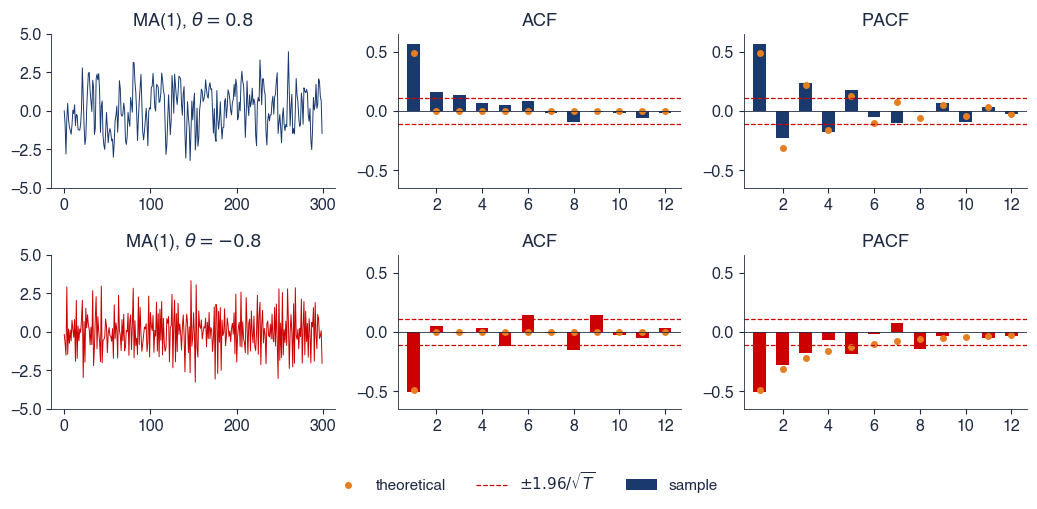

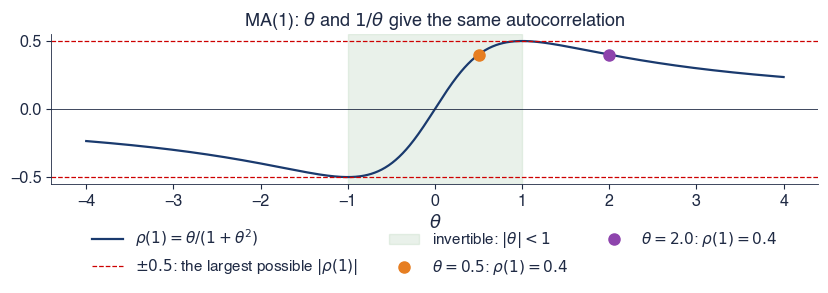

{'r05': 0.4, 'r2': 0.4}

In [8]:
def fig_ma1(n=300, nlags=12, save_it=True):
    """MA(1) with theta = 0.8 and -0.8: paths, sample ACF (cuts off after lag 1) and sample PACF (decays)."""
    rng = np.random.default_rng(SEED + 1)
    e = rng.normal(size=n + 1)
    fig, ax = plt.subplots(2, 3, figsize=(10.4, 4.6))
    out = {}
    for i, (th, c) in enumerate([(0.8, st.MainBlue), (-0.8, st.IDAred)]):
        x = e[1:] + th * e[:-1]
        ax[i, 0].plot(x, color=c, lw=0.7)
        ax[i, 0].set_title(rf'MA(1), $\theta = {th}$')
        ax[i, 0].set_ylim(-5, 5)
        r, pc = sample_acf(x, nlags), sample_pacf(x, nlags)
        acf_bars(ax[i, 1], r, n, color=c, theory=theoretical_acf(theta=[th], nlags=nlags),
                 label='sample' if i == 0 else '_nolegend_', theory_label='theoretical' if i == 0 else '_nolegend_')
        acf_bars(ax[i, 2], pc, n, color=c, theory=theoretical_pacf(theta=[th], nlags=nlags), label='_nolegend_',
                 theory_label='_nolegend_')
        for a in ax[i, 1:]:
            a.set_ylim(-0.65, 0.65)
            if i == 1:
                a.get_lines()[1].set_label('_nolegend_')
        ax[i, 1].set_title('ACF')
        ax[i, 2].set_title('PACF')
        out[str(th)] = {'r1': float(r[0]), 'r2': float(r[1]), 'p1': float(pc[0]), 'p2': float(pc[1]),
                        'p3': float(pc[2]), 'rho1_th': th / (1 + th ** 2)}
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_ma1', save_it)
    return out


def fig_ma1_rho(save_it=True):
    """rho(1) = theta / (1 + theta^2) of an MA(1): maximum 0.5 at theta = 1; theta and 1/theta give the same rho(1)."""
    th = np.linspace(-4, 4, 801)
    r = th / (1 + th ** 2)
    fig, ax = plt.subplots(figsize=(8.6, 3.3))
    ax.plot(th, r, color=st.MainBlue, lw=1.6, label=r'$\rho(1) = \theta/(1 + \theta^2)$')
    ax.axhline(0.5, color=st.IDAred, ls='--', lw=0.9, label=r'$\pm 0.5$: the largest possible $|\rho(1)|$')
    ax.axhline(-0.5, color=st.IDAred, ls='--', lw=0.9, label='_nolegend_')
    ax.axvspan(-1, 1, color=st.Forest, alpha=0.10, label=r'invertible: $|\theta| < 1$')
    for t0, c in [(0.5, st.Orange), (2.0, st.Purple)]:
        ax.plot(t0, t0 / (1 + t0 ** 2), 'o', ms=8, color=c, label=rf'$\theta = {t0}$: $\rho(1) = 0.4$')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlabel(r'$\theta$')
    ax.set_title(r'MA(1): $\theta$ and $1/\theta$ give the same autocorrelation')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save('tsa_ch2_ma1_rho', save_it)
    return {'r05': 0.5 / 1.25, 'r2': 2 / 5}


fig_ma1(save_it=False)
fig_ma1_rho(save_it=False)

## 3. ARMA: identification patterns and impulse responses

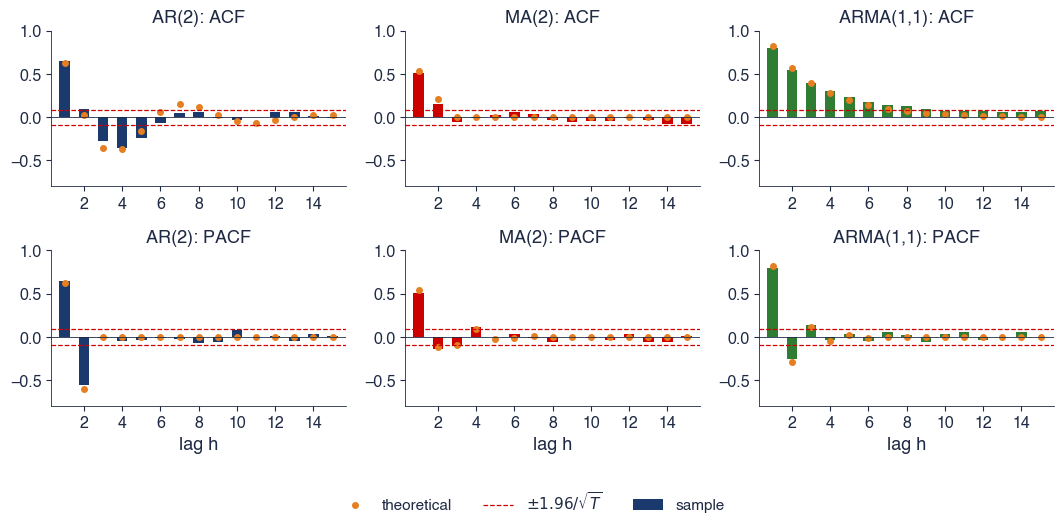

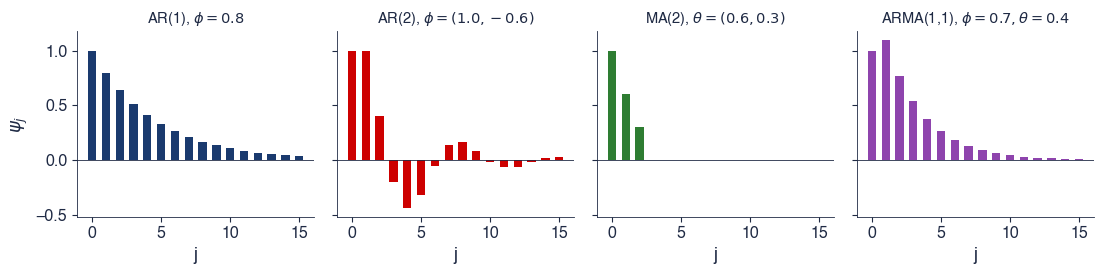

{'AR(1)': [1.0,
  0.8,
  0.6400000000000001,
  0.5120000000000001,
  0.40960000000000013,
  0.32768000000000014],
 'AR(2)': [1.0,
  1.0,
  0.4,
  -0.19999999999999996,
  -0.43999999999999995,
  -0.31999999999999995],
 'MA(2)': [1.0, 0.6, 0.3, 0.0, 0.0, 0.0],
 'ARMA(1': [1.0,
  1.1,
  0.77,
  0.5389999999999999,
  0.3772999999999999,
  0.2641099999999999]}

In [9]:
def fig_patterns(n=500, nlags=15, save_it=True):
    """Theoretical (dots) and sample (bars, one simulated path of n = 500) ACF and PACF of AR(2), MA(2), ARMA(1,1)."""
    rng = np.random.default_rng(SEED + 2)
    cols = [st.MainBlue, st.IDAred, st.Forest]
    fig, ax = plt.subplots(2, 3, figsize=(10.8, 4.8))
    out = {}
    for j, ((lab, (ph, th)), c) in enumerate(zip(MODELS.items(), cols)):
        x = simulate_arma(ph, th, n=n, rng=rng)
        r, pc = sample_acf(x, nlags), sample_pacf(x, nlags)
        acf_bars(ax[0, j], r, n, color=c, theory=theoretical_acf(ph, th, nlags),
                 label='sample' if j == 0 else '_nolegend_', theory_label='theoretical' if j == 0 else '_nolegend_')
        acf_bars(ax[1, j], pc, n, color=c, theory=theoretical_pacf(ph, th, nlags), label='_nolegend_',
                 theory_label='_nolegend_')
        ax[0, j].set_title(f'{lab}: ACF')
        ax[1, j].set_title(f'{lab}: PACF')
        for a in ax[:, j]:
            a.set_ylim(-0.8, 1.0)
            if j:
                a.get_lines()[1].set_label('_nolegend_')
        ax[1, j].get_lines()[1].set_label('_nolegend_')
        ax[1, j].set_xlabel('lag h')
        out[lab] = {'r': [float(v) for v in r[:4]], 'p': [float(v) for v in pc[:4]],
                    'rt': [float(v) for v in theoretical_acf(ph, th, 4)], 'pt': [float(v) for v in theoretical_pacf(ph, th, 4)]}
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_patterns', save_it)
    return out


def fig_psi(n=16, save_it=True):
    """psi weights (impulse responses) of AR(1) phi = 0.8, AR(2) (1.0, -0.6), MA(2) (0.6, 0.3) and ARMA(1,1)."""
    cases = {r'AR(1), $\phi = 0.8$': ([0.8], [], st.MainBlue), r'AR(2), $\phi = (1.0, -0.6)$': ([1.0, -0.6], [], st.IDAred),
             r'MA(2), $\theta = (0.6, 0.3)$': ([], [0.6, 0.3], st.Forest),
             r'ARMA(1,1), $\phi = 0.7, \theta = 0.4$': ([0.7], [0.4], st.Purple)}
    fig, ax = plt.subplots(1, 4, figsize=(11.2, 2.9), sharey=True)
    out = {}
    for a, (lab, (ph, th, c)) in zip(ax, cases.items()):
        psi = psi_weights(ph, th, n)
        a.bar(np.arange(n), psi, width=0.6, color=c)
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_title(lab, fontsize=10.5)
        a.set_xlabel('j')
        out[lab.split(',')[0]] = [float(v) for v in psi[:6]]
    ax[0].set_ylabel(r'$\psi_j$')
    plt.tight_layout()
    save('tsa_ch2_psi', save_it)
    return out


fig_patterns(save_it=False)
fig_psi(save_it=False)

## 4. Estimators by simulation

- Yule–Walker, conditional least squares, maximum likelihood; $T = 100$.

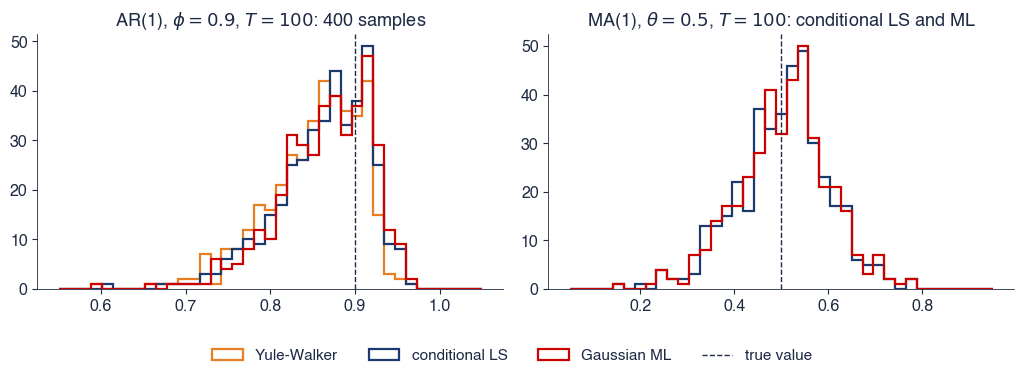

{'ar_yw_mean': 0.8525454271010767,
 'ar_cls_mean': 0.8636601502237036,
 'ar_ml_mean': 0.8656468870945855,
 'ar_yw_sd': 0.056039802813794115,
 'ar_cls_sd': 0.05497369417698157,
 'ar_ml_sd': 0.05444211916425696,
 'ma_cls_mean': 0.5037751786114133,
 'ma_ml_mean': 0.5056741363629402,
 'ma_cls_sd': 0.09688832200201189,
 'ma_ml_sd': 0.09805327737068108,
 'ar_se_asy': 0.04358898943540673,
 'ma_se_asy': 0.08660254037844387,
 'nrep': 400,
 'T': 100}

In [10]:
def css_ma1(x):
    """Conditional least squares for X_t = mu + e_t + theta e_{t-1}, with e_0 = 0: minimise the sum of squares."""
    from scipy.optimize import minimize_scalar
    x = np.asarray(x, float) - np.mean(x)

    def ssr(th):
        e, s = 0.0, 0.0
        for v in x:
            e = v - th * e
            s += e * e
        return s
    return float(minimize_scalar(ssr, bounds=(-0.99, 0.99), method='bounded').x)


def ar1_estimates(x):
    """Yule-Walker, conditional least squares (OLS of X_t on X_{t-1}) and Gaussian ML for an AR(1)."""
    yw = float(yule_walker(x, order=1, method='mle')[0][0])
    y, z = x[1:], x[:-1]
    Z = np.c_[np.ones_like(z), z]
    ols = float(np.linalg.lstsq(Z, y, rcond=None)[0][1])
    ml = float(fit_arma(x, 1, 0).params[1])
    return yw, ols, ml


def fig_estimators(nrep=400, T=100, phi=0.9, theta=0.5, save_it=True):
    """Sampling distributions of YW, CLS and ML for an AR(1) (phi = 0.9) and of CLS and ML for an MA(1)
    (theta = 0.5), T = 100."""
    rng = np.random.default_rng(SEED + 3)
    A = np.array([ar1_estimates(simulate_arma([phi], n=T, rng=rng)) for _ in range(nrep)])
    M = []
    for _ in range(nrep):
        x = simulate_arma([], [theta], n=T, rng=rng)
        M.append((css_ma1(x), float(fit_arma(x, 0, 1).params[1])))
    M = np.array(M)
    fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.4))
    bins = np.linspace(0.55, 1.05, 40)
    for k, (lab, c) in enumerate([('Yule-Walker', st.Orange), ('conditional LS', st.MainBlue), ('Gaussian ML', st.IDAred)]):
        ax[0].hist(A[:, k], bins=bins, histtype='step', lw=1.6, color=c, label=lab)
    ax[0].axvline(phi, color=st.DarkText, ls='--', lw=1, label='true value')
    ax[0].set_title(rf'AR(1), $\phi = {phi}$, $T = {T}$: {nrep} samples')
    bins = np.linspace(0.05, 0.95, 40)
    ax[1].hist(M[:, 0], bins=bins, histtype='step', lw=1.6, color=st.MainBlue, label='_nolegend_')
    ax[1].hist(M[:, 1], bins=bins, histtype='step', lw=1.6, color=st.IDAred, label='_nolegend_')
    ax[1].axvline(theta, color=st.DarkText, ls='--', lw=1, label='_nolegend_')
    ax[1].set_title(rf'MA(1), $\theta = {theta}$, $T = {T}$: conditional LS and ML')
    st.fig_legend_bottom(fig, ncol=4, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_estimators', save_it)
    names = ['yw', 'cls', 'ml']
    out = {f'ar_{k}_mean': float(A[:, i].mean()) for i, k in enumerate(names)}
    out.update({f'ar_{k}_sd': float(A[:, i].std()) for i, k in enumerate(names)})
    out.update({'ma_cls_mean': float(M[:, 0].mean()), 'ma_ml_mean': float(M[:, 1].mean()),
                'ma_cls_sd': float(M[:, 0].std()), 'ma_ml_sd': float(M[:, 1].std()),
                'ar_se_asy': float(np.sqrt((1 - phi ** 2) / T)), 'ma_se_asy': float(np.sqrt((1 - theta ** 2) / T)),
                'nrep': nrep, 'T': T})
    return out


fig_estimators(save_it=False)

## 5. Model selection and the Ljung–Box degrees of freedom

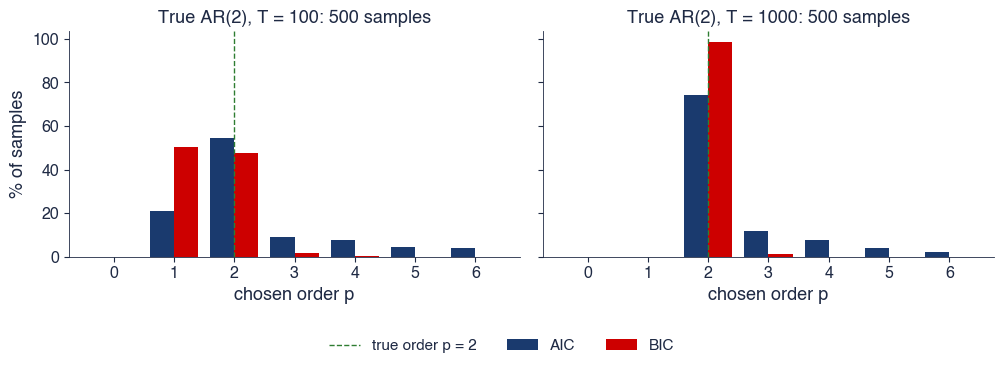

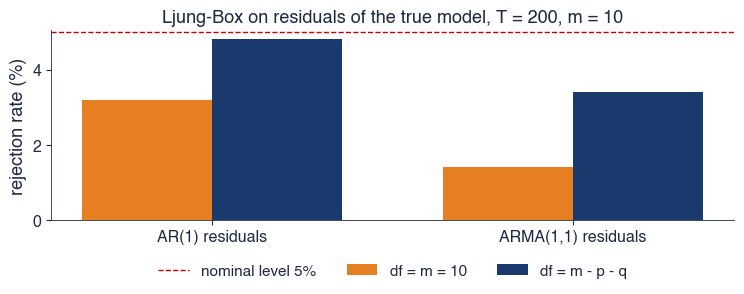

{'AR(1)': [3.2, 4.8], 'ARMA(1,1)': [1.4, 3.4], 'T': 200, 'm': 10, 'nrep': 1000}

In [11]:
def ar_ols_ic(x, pmax=6):
    """AR(p), p = 0..pmax, fitted by OLS on the same sample t = pmax+1..T; AIC and BIC per observation count."""
    x = np.asarray(x, float)
    T = len(x)
    y = x[pmax:]
    n = len(y)
    aic, bic = [], []
    for p in range(pmax + 1):
        Z = np.c_[np.ones(n)] if p == 0 else np.c_[np.ones(n), np.column_stack([x[pmax - i:T - i] for i in range(1, p + 1)])]
        b = np.linalg.lstsq(Z, y, rcond=None)[0]
        s2 = np.mean((y - Z @ b) ** 2)
        ll = -0.5 * n * (np.log(2 * np.pi * s2) + 1)
        k = p + 2
        aic.append(-2 * ll + 2 * k)
        bic.append(-2 * ll + k * np.log(n))
    return int(np.argmin(aic)), int(np.argmin(bic))


def fig_ic(nrep=500, phi=(0.5, 0.25), pmax=6, save_it=True):
    """How often AIC and BIC choose each AR order when the truth is AR(2), for T = 100 and T = 1000."""
    rng = np.random.default_rng(SEED + 4)
    fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.3), sharey=True)
    out = {}
    for a, T in zip(ax, [100, 1000]):
        ch = np.array([ar_ols_ic(simulate_arma(phi, n=T, rng=rng), pmax) for _ in range(nrep)])
        fa = np.bincount(ch[:, 0], minlength=pmax + 1) / nrep
        fb = np.bincount(ch[:, 1], minlength=pmax + 1) / nrep
        p = np.arange(pmax + 1)
        a.bar(p - 0.2, 100 * fa, width=0.4, color=st.MainBlue, label='AIC')
        a.bar(p + 0.2, 100 * fb, width=0.4, color=st.IDAred, label='BIC')
        a.axvline(2, color=st.Forest, ls='--', lw=1, label='true order p = 2')
        a.set_title(f'True AR(2), T = {T}: {nrep} samples')
        a.set_xlabel('chosen order p')
        a.set_xticks(p)
        out[str(T)] = {'aic_true': float(fa[2]), 'bic_true': float(fb[2]), 'aic_over': float(fa[3:].sum()),
                       'bic_over': float(fb[3:].sum()), 'aic_under': float(fa[:2].sum()), 'bic_under': float(fb[:2].sum())}
    ax[0].set_ylabel('% of samples')
    for a in ax[1:]:
        for b in a.patches + a.get_lines():
            b.set_label('_nolegend_')
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_ic', save_it)
    return out


def fig_lb_df(nrep=1000, T=200, m=10, save_it=True):
    """Ljung-Box on the residuals of a correctly specified model: rejection rate at 5% with m and with m - p - q
    degrees of freedom (AR(1) phi = 0.7 fitted by OLS; ARMA(1,1) phi = 0.7, theta = 0.4 fitted by ML)."""
    rng = np.random.default_rng(SEED + 5)
    rej = {'AR(1)': [0, 0], 'ARMA(1,1)': [0, 0]}
    for i in range(nrep):
        x = simulate_arma([0.7], n=T, rng=rng)
        Z = np.c_[np.ones(T - 1), x[:-1]]
        e = x[1:] - Z @ np.linalg.lstsq(Z, x[1:], rcond=None)[0]
        rej['AR(1)'][0] += ljung_box(e, m)['lb_p'] < 0.05
        rej['AR(1)'][1] += ljung_box(e, m, m - 1)['lb_p'] < 0.05
        if i < nrep // 2:
            x = simulate_arma([0.7], [0.4], n=T, rng=rng)
            e = fit_arma(x, 1, 1).resid[1:]
            rej['ARMA(1,1)'][0] += ljung_box(e, m)['lb_p'] < 0.05
            rej['ARMA(1,1)'][1] += ljung_box(e, m, m - 2)['lb_p'] < 0.05
    out = {'AR(1)': [100 * v / nrep for v in rej['AR(1)']], 'ARMA(1,1)': [100 * v / (nrep // 2) for v in rej['ARMA(1,1)']],
           'T': T, 'm': m, 'nrep': nrep}
    fig, ax = plt.subplots(figsize=(7.6, 3.2))
    xs = np.arange(2)
    ax.bar(xs - 0.18, [out['AR(1)'][0], out['ARMA(1,1)'][0]], width=0.36, color=st.Orange, label=f'df = m = {m}')
    ax.bar(xs + 0.18, [out['AR(1)'][1], out['ARMA(1,1)'][1]], width=0.36, color=st.MainBlue, label='df = m - p - q')
    ax.axhline(5, color=st.IDAred, ls='--', lw=1, label='nominal level 5%')
    ax.set_xticks(xs)
    ax.set_xticklabels(['AR(1) residuals', 'ARMA(1,1) residuals'])
    ax.set_ylabel('rejection rate (%)')
    ax.set_title(f'Ljung-Box on residuals of the true model, T = {T}, m = {m}')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    plt.tight_layout()
    save('tsa_ch2_lb_df', save_it)
    return out


fig_ic(save_it=False)
fig_lb_df(save_it=False)

## 6. Forecasting: mean reversion and intervals

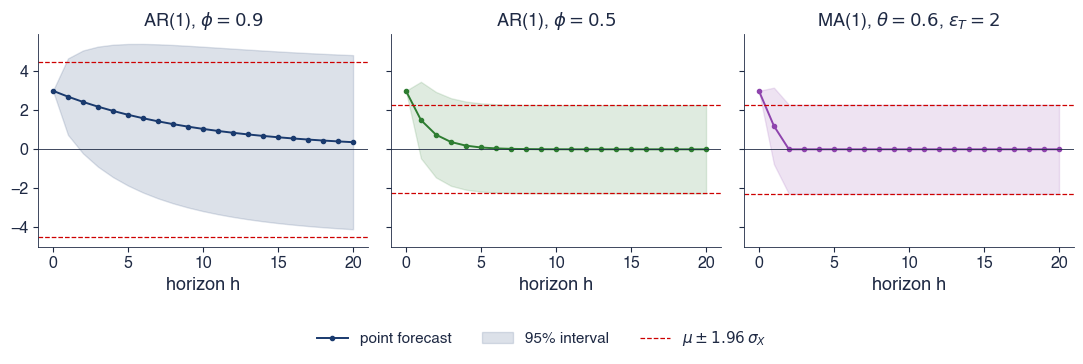

{'\\phi = 0.9': {'f1': 2.7,
  'f5': 1.7714700000000003,
  'se1': 1.0,
  'se5': 1.8514881069021212,
  'se_inf': 2.294157338705618},
 '\\phi = 0.5': {'f1': 1.5,
  'f5': 0.09375,
  'se1': 1.0,
  'se5': 1.1541365820387117,
  'se_inf': 1.1547005383792515},
 'ma': {'f1': 1.2,
  'f5': 0.0,
  'se1': 1.0,
  'se5': 1.16619037896906,
  'se_inf': 1.16619037896906}}

In [12]:
def fig_forecast_theory(H=20, save_it=True):
    """AR(1) (phi = 0.9 and 0.5) and MA(1) (theta = 0.6) forecasts from X_T = 3 (mu = 0, sigma = 1) with 95%
    intervals: the forecast reverts to the mean, the interval widens to the unconditional band."""
    h = np.arange(0, H + 1)
    fig, ax = plt.subplots(1, 3, figsize=(11.0, 3.2), sharey=True)
    out = {}
    for a, (lab, ph, th, c) in zip(ax, [(r'AR(1), $\phi = 0.9$', [0.9], [], st.MainBlue),
                                        (r'AR(1), $\phi = 0.5$', [0.5], [], st.Forest),
                                        (r'MA(1), $\theta = 0.6$, $\varepsilon_T = 2$', [], [0.6], st.Purple)]):
        psi = psi_weights(ph, th, H + 1)
        if ph:
            f = 3 * ph[0] ** h
        else:
            f = np.r_[3, 0.6 * 2, np.zeros(H - 1)]
        se = np.r_[0, np.sqrt(np.cumsum(psi[:H] ** 2))]
        a.plot(h, f, 'o-', ms=3, color=c, label='point forecast' if a is ax[0] else '_nolegend_')
        a.fill_between(h, f - 1.96 * se, f + 1.96 * se, color=c, alpha=0.15,
                       label='95% interval' if a is ax[0] else '_nolegend_')
        u = 1.96 * np.sqrt(np.sum(psi_weights(ph, th, 400) ** 2))
        a.axhline(u, color=st.IDAred, ls='--', lw=0.9, label=r'$\mu \pm 1.96\,\sigma_X$' if a is ax[0] else '_nolegend_')
        a.axhline(-u, color=st.IDAred, ls='--', lw=0.9, label='_nolegend_')
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_title(lab)
        a.set_xlabel('horizon h')
        out[lab.split('$')[1] if ph else 'ma'] = {'f1': float(f[1]), 'f5': float(f[5]), 'se1': float(se[1]),
                                                  'se5': float(se[5]), 'se_inf': float(u / 1.96)}
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_forecast_theory', save_it)
    return out


fig_forecast_theory(save_it=False)

## 7. Box–Jenkins: Romanian annual GDP growth

- Identification, a grid of ARMA($p,q$) models with AIC, BIC and Ljung–Box, diagnostics, forecasts.

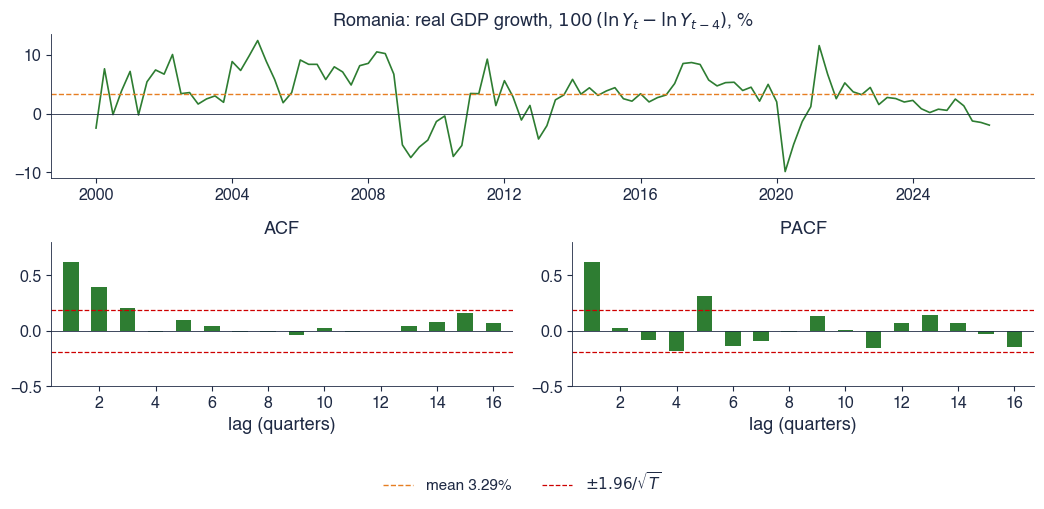

,p,q,k,loglik,aic,bic,lb8,lb8_df,lb8_p,sigma
0,0,0,2,-305.831,615.661,620.988,64.905,8,0.000,4.333
1,0,1,3,-284.187,574.374,582.364,20.361,7,0.005,3.522
2,0,2,4,-281.571,571.142,581.795,13.198,6,0.040,3.434
3,0,3,5,-270.020,550.041,563.358,5.350,5,0.375,3.065
4,1,0,3,-279.666,565.331,573.321,16.229,7,0.023,3.377
5,1,1,4,-279.662,567.325,577.978,16.063,6,0.013,3.377
6,1,2,5,-278.125,566.250,579.567,10.655,5,0.059,3.322
7,1,3,6,-268.484,548.969,564.949,2.481,4,0.648,3.019
8,2,0,4,-279.662,567.323,577.977,13.405,6,0.037,3.377
9,2,1,5,-276.842,563.684,577.002,8.356,5,0.138,3.278


In [13]:
def gdp_models(y, pmax=3, qmax=3):
    """All ARMA(p, q), p <= pmax, q <= qmax, by Gaussian ML: log-likelihood, AIC, BIC, Ljung-Box on residuals."""
    rows = []
    for p in range(pmax + 1):
        for q in range(qmax + 1):
            try:
                r = fit_arma(y, p, q)
            except Exception:
                continue
            e = r.resid[max(p, q):]
            lb = ljung_box(e, 8, 8 - p - q)
            rows.append({'p': p, 'q': q, 'k': p + q + 2, 'loglik': float(r.llf), 'aic': float(r.aic), 'bic': float(r.bic),
                         'lb8': lb['lb'], 'lb8_df': lb['df'], 'lb8_p': lb['lb_p'], 'sigma': float(np.sqrt(r.params[-1]))})
    return pd.DataFrame(rows)


def fig_gdp_ident(nlags=16, save_it=True):
    """Identification: Romanian annual real GDP growth since 2000, its ACF and PACF."""
    y = ro_gdp_growth('yoy')
    T = len(y)
    fig = plt.figure(figsize=(10.6, 4.6))
    a0 = fig.add_subplot(2, 1, 1)
    a0.plot(y.index, y, color=st.Forest, lw=1.2)
    a0.axhline(y.mean(), color=st.Orange, ls='--', lw=1, label=f'mean {y.mean():.2f}%')
    a0.axhline(0, color=st.DarkText, lw=0.6)
    a0.set_title(r'Romania: real GDP growth, $100\,(\ln Y_t - \ln Y_{t-4})$, %')
    a1, a2 = fig.add_subplot(2, 2, 3), fig.add_subplot(2, 2, 4)
    r, pc = sample_acf(y, nlags), sample_pacf(y, nlags)
    acf_bars(a1, r, T, color=st.Forest, label='_nolegend_')
    acf_bars(a2, pc, T, color=st.Forest, label='_nolegend_', band=True)
    a2.get_lines()[0].set_label('_nolegend_')
    a1.set_title('ACF')
    a2.set_title('PACF')
    for a in (a1, a2):
        a.set_ylim(-0.5, 0.8)
        a.set_xlabel('lag (quarters)')
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_gdp_ident', save_it)
    i = int(np.argmin(y.values))
    return {'T': T, 'first': y.index[0].strftime('%Y-%m-%d'), 'last': y.index[-1].strftime('%Y-%m-%d'),
            'mean': float(y.mean()), 'sd': float(y.std()), 'r': [float(v) for v in r[:6]], 'p': [float(v) for v in pc[:6]],
            'min': float(y.min()), 'min_d': y.index[i].strftime('%Y-%m-%d'), 'max': float(y.max()),
            'max_d': y.idxmax().strftime('%Y-%m-%d'), 'last_v': float(y.iloc[-1]), 'band': 1.96 / np.sqrt(T),
            'lb8': ljung_box(y, 8)}


def gdp_table(save_csv=True):
    y = ro_gdp_growth('yoy')
    t = gdp_models(y)
    if save_csv:
        t.round(4).to_csv(os.path.join(HERE, 'ch2_gdp_models.csv'), index=False)
    ia, ib = int(t['aic'].idxmin()), int(t['bic'].idxmin())
    sel = lambda p, q: t[(t.p == p) & (t.q == q)].iloc[0].to_dict()   # noqa: E731
    out = {'aic_best': [int(t.loc[ia, 'p']), int(t.loc[ia, 'q'])], 'bic_best': [int(t.loc[ib, 'p']), int(t.loc[ib, 'q'])],
           'rows': {f'{p}{q}': sel(p, q) for p, q in [(0, 0), (1, 0), (2, 0), (0, 3), (1, 1), (1, 3), (2, 3), (3, 3)]
                    if len(t[(t.p == p) & (t.q == q)])}}
    for k, (p, q) in [('aic', out['aic_best']), ('bic', out['bic_best'])]:
        r = fit_arma(y, p, q)
        out[f'{k}_params'] = {n: float(v) for n, v in zip(r.param_names, r.params)}
        out[f'{k}_se'] = {n: float(v) for n, v in zip(r.param_names, r.bse)}
        th = [v for n, v in zip(r.param_names, r.params) if n.startswith('ma.')]
        out[f'{k}_ma_root_mod'] = [float(v) for v in np.sort(np.abs(np.roots(np.r_[th[::-1], 1.0])))] if th else []
    return out


def fig_gdp_diag(p=0, q=3, save_it=True):
    """Residual diagnostics of the chosen model: residuals, residual ACF, Ljung-Box p-values with m - p - q degrees of
    freedom, and a Normal QQ plot."""
    y = ro_gdp_growth('yoy')
    r = fit_arma(y, p, q)
    e = pd.Series(r.resid, index=y.index).iloc[max(p, q):]
    T = len(e)
    fig, ax = plt.subplots(2, 2, figsize=(10.4, 4.9))
    ax[0, 0].plot(e.index, e, color=st.MainBlue, lw=1)
    ax[0, 0].axhline(0, color=st.DarkText, lw=0.6)
    ax[0, 0].set_title(f'Residuals of ARMA({p},{q})')
    acf_bars(ax[0, 1], sample_acf(e, 16), T, color=st.MainBlue, label='_nolegend_')
    ax[0, 1].get_lines()[0].set_label(r'$\pm 1.96/\sqrt{T}$')
    ax[0, 1].set_title('ACF of the residuals')
    ax[0, 1].set_ylim(-0.4, 0.4)
    ms = np.arange(p + q + 1, 17)
    pv = [ljung_box(e, m, m - p - q)['lb_p'] for m in ms]
    ax[1, 0].plot(ms, pv, 'o', color=st.MainBlue, label='_nolegend_')
    ax[1, 0].axhline(0.05, color=st.Orange, ls='--', lw=1, label='5% level')
    ax[1, 0].set_ylim(0, 1)
    ax[1, 0].set_xlabel('m')
    ax[1, 0].set_title(f'Ljung-Box p-values, df = m - {p + q}')
    (osm, osr), (sl, ic, _) = stats.probplot(e / e.std(), dist='norm')
    ax[1, 1].plot(osm, osr, 'o', ms=3.5, color=st.MainBlue, label='_nolegend_')
    ax[1, 1].plot(osm, sl * osm + ic, color=st.IDAred, lw=1, label='Normal reference line')
    ax[1, 1].set_title('Normal QQ plot of the standardised residuals')
    ax[1, 1].set_xlabel('theoretical quantiles')
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_gdp_diag', save_it)
    jb = stats.jarque_bera(e)
    i = int(np.argmax(np.abs(e.values)))
    lb8 = ljung_box(e, 8, 8 - p - q)
    lb8_wrong = ljung_box(e, 8)
    return {'lb8': lb8, 'lb8_wrong_p': lb8_wrong['lb_p'], 'lb16': ljung_box(e, 16, 16 - p - q), 'jb': float(jb.statistic),
            'jb_p': float(jb.pvalue), 'skew': float(stats.skew(e)), 'kurt': float(stats.kurtosis(e) + 3),
            'out_d': e.index[i].strftime('%Y-%m-%d'), 'out_v': float(e.iloc[i]), 'out_z': float(e.iloc[i] / e.std()),
            'min_p': float(min(pv)), 'lbsq8': ljung_box(e ** 2, 8)}


def fig_gdp_forecast(models=((0, 3), (1, 0)), H=8, save_it=True):
    """Forecasts of Romanian annual GDP growth, 8 quarters ahead, from MA(3) and AR(1), with 95% intervals."""
    y = ro_gdp_growth('yoy')
    idx = pd.date_range(y.index[-1] + pd.offsets.QuarterBegin(1, startingMonth=1), periods=H, freq='QS')
    fig, ax = plt.subplots(figsize=(10.2, 3.6))
    ax.plot(y.index[-40:], y.iloc[-40:], color=st.DarkText, lw=1.2, label='observed')
    out = {}
    for (p, q), c in zip(models, [st.IDAred, st.MainBlue]):
        r = fit_arma(y, p, q)
        f = r.get_forecast(H)
        m, ci = f.predicted_mean, f.conf_int(alpha=0.05)
        lab = f'ARMA({p},{q})'
        ax.plot(idx, m, 'o-', ms=3, color=c, label=f'{lab} forecast')
        ax.fill_between(idx, ci[:, 0], ci[:, 1], color=c, alpha=0.13, label=f'{lab}: 95% interval')
        out[lab] = {'f': [float(v) for v in m], 'lo': [float(v) for v in ci[:, 0]], 'hi': [float(v) for v in ci[:, 1]],
                    'mu': float(r.params[0])}
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_title('Romania: annual real GDP growth (%), forecasts for the next 8 quarters')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    plt.tight_layout()
    save('tsa_ch2_gdp_forecast', save_it)
    out['first'] = idx[0].strftime('%Y-%m-%d')
    out['last'] = idx[-1].strftime('%Y-%m-%d')
    return out


fig_gdp_ident(save_it=False)
tab = gdp_models(ro_gdp_growth('yoy'))
tab.round(3)

AIC: [1, 3] BIC: [0, 3]


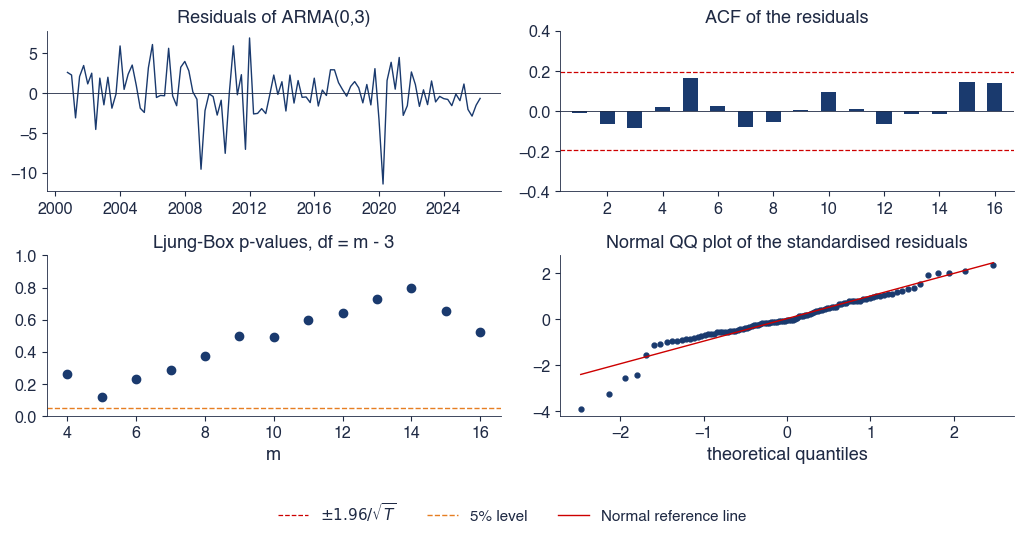

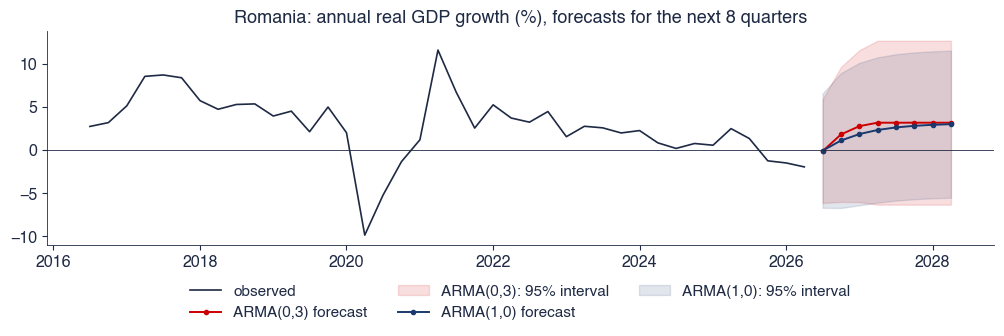

{'lb8': {'lb': 5.3501232930940565, 'df': 5, 'lb_p': 0.3746603422378767},
 'lb8_wrong_p': 0.7195824311510395,
 'lb16': {'lb': 12.03649996261831, 'df': 13, 'lb_p': 0.5246531471045384},
 'jb': 38.959716692651234,
 'jb_p': 3.4674085195895974e-09,
 'skew': -0.7537330364564533,
 'kurt': 5.608742662295556,
 'out_d': '2020-04-01',
 'out_v': -11.434112095239316,
 'out_z': -3.893023903769396,
 'min_p': 0.120997611876376,
 'lbsq8': {'lb': 4.793203300053167, 'df': 8, 'lb_p': 0.779432911957189}}

In [14]:
T = gdp_table(save_csv=False)
print('AIC:', T['aic_best'], 'BIC:', T['bic_best'])
diag = fig_gdp_diag(*T['bic_best'], save_it=False)
fc = fig_gdp_forecast(models=(tuple(T['bic_best']), (1, 0)), save_it=False)
diag

## 8. More real series: inflation, daily returns, sunspots

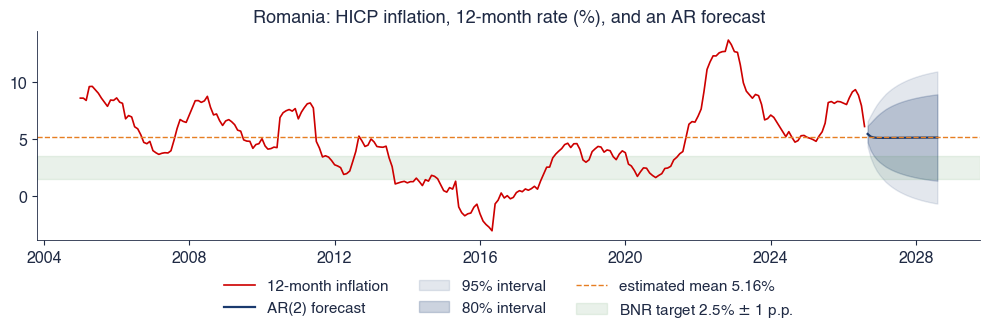

{'p': 2, 'params': [5.162800696096462, 1.3204460093468322, -0.34412191162821537, 0.32278298733725896], 'mu': 5.162800696096462, 'sum_phi': 0.9763240977186168}


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


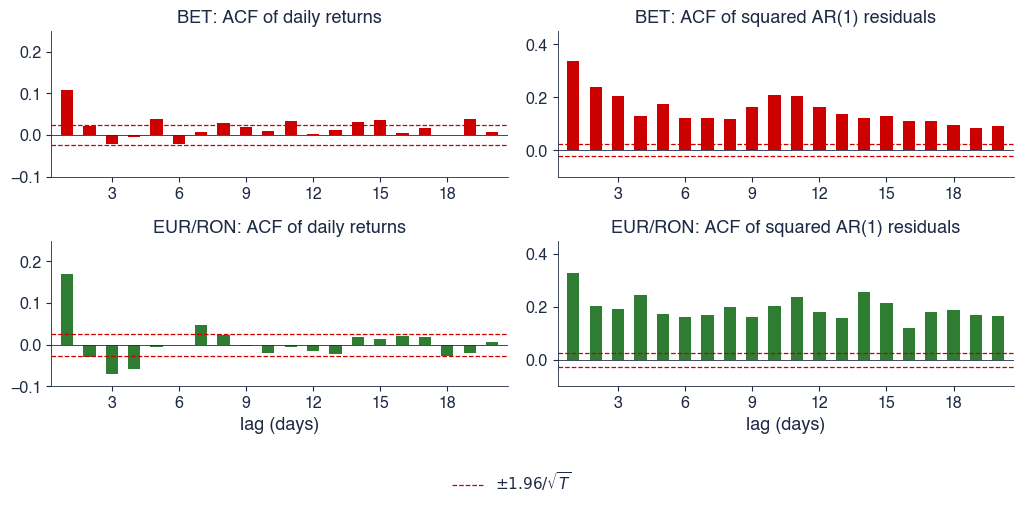

,phi,t,R2,kurt
bet,0.109,20.890,0.012,14.028
eurron,0.170,30.597,0.029,17.024


In [15]:
def fig_inflation(H=24, save_it=True):
    """Romanian 12-month HICP inflation since 2005: AR(p) order by BIC (p <= 6), ML fit, 24-month forecast with 80% and
    95% intervals; the BNR target band 2.5% +- 1 p.p. for reference."""
    y = ro_inflation()
    bic = []
    for p in range(1, 7):
        bic.append(fit_arma(y.values, p, 0).bic)
    p = int(np.argmin(bic) + 1)
    r = fit_arma(y.values, p, 0)
    f = r.get_forecast(H)
    m, c95, c80 = f.predicted_mean, f.conf_int(alpha=0.05), f.conf_int(alpha=0.20)
    idx = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=H, freq='MS')
    fig, ax = plt.subplots(figsize=(10.2, 3.6))
    ax.plot(y.index, y, color=st.IDAred, lw=1.2, label='12-month inflation')
    ax.plot(idx, m, color=st.MainBlue, lw=1.6, label=f'AR({p}) forecast')
    ax.fill_between(idx, c95[:, 0], c95[:, 1], color=st.MainBlue, alpha=0.12, label='95% interval')
    ax.fill_between(idx, c80[:, 0], c80[:, 1], color=st.MainBlue, alpha=0.22, label='80% interval')
    mu = float(r.params[0])
    ax.axhline(mu, color=st.Orange, ls='--', lw=1, label=f'estimated mean {mu:.2f}%')
    ax.axhspan(1.5, 3.5, color=st.Forest, alpha=0.10, label='BNR target 2.5% $\\pm$ 1 p.p.')
    ax.set_title('Romania: HICP inflation, 12-month rate (%), and an AR forecast')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    plt.tight_layout()
    save('tsa_ch2_inflation', save_it)
    ph = r.params[1:1 + p]
    ir = inverse_roots(ph)
    return {'p': p, 'bic': [float(v) for v in bic], 'params': [float(v) for v in r.params], 'se': [float(v) for v in r.bse],
            'mu': mu, 'sum_phi': float(np.sum(ph)), 'inv_mod': [float(abs(z)) for z in ir], 'T': int(len(y)),
            'last': y.index[-1].strftime('%Y-%m-%d'), 'last_v': float(y.iloc[-1]), 'f': [float(v) for v in m],
            'lo95': [float(v) for v in c95[:, 0]], 'hi95': [float(v) for v in c95[:, 1]],
            'f_last': idx[-1].strftime('%Y-%m-%d'), 'max': float(y.max()), 'max_d': y.idxmax().strftime('%Y-%m-%d'),
            'lb12': ljung_box(r.resid[p:], 12, 12 - p), 'sigma': float(np.sqrt(r.params[-1]))}


def returns_ar(name, start=None):
    """AR(1) for daily log returns (%): estimate, standard error, R^2, Ljung-Box on residuals and on squared residuals,
    Jarque-Bera; the orders chosen by AIC and BIC among ARMA(p, q), p, q <= 2."""
    r = log_returns(name, start=start)
    m = fit_arma(r.values, 1, 0)
    e = m.resid[1:]
    jb = stats.jarque_bera(e)
    ic = []
    for p in range(3):
        for q in range(3):
            try:
                f = fit_arma(r.values, p, q)
                ic.append((p, q, f.aic, f.bic))
            except Exception:
                pass
    ic = pd.DataFrame(ic, columns=['p', 'q', 'aic', 'bic'])
    a, b = ic.loc[ic.aic.idxmin()], ic.loc[ic.bic.idxmin()]
    return {'T': int(len(r)), 'first': r.index[0].strftime('%Y-%m-%d'), 'phi': float(m.params[1]), 'se': float(m.bse[1]),
            't': float(m.params[1] / m.bse[1]), 'r2': float(1 - np.var(e) / np.var(r.values[1:])),
            'lb10': ljung_box(e, 10, 9), 'lbsq10': ljung_box(e ** 2, 10), 'jb': float(jb.statistic), 'jb_p': float(jb.pvalue),
            'kurt': float(stats.kurtosis(e) + 3), 'aic': [int(a.p), int(a.q)], 'bic': [int(b.p), int(b.q)],
            'sd': float(r.std()), 'lb10_raw': ljung_box(r.values, 10)}


def fig_returns(nlags=20, save_it=True):
    """BET and EUR/RON daily returns: ACF of the returns, ACF of the squared residuals of an AR(1)."""
    fig, ax = plt.subplots(2, 2, figsize=(10.4, 4.6))
    out = {}
    for i, (k, lab, c) in enumerate([('bet', 'BET', st.IDAred), ('eurron', 'EUR/RON', st.Forest)]):
        r = log_returns(k)
        e = fit_arma(r.values, 1, 0).resid[1:]
        T = len(r)
        acf_bars(ax[i, 0], sample_acf(r, nlags), T, color=c, label='_nolegend_')
        acf_bars(ax[i, 1], sample_acf(e ** 2, nlags), T, color=c, label='_nolegend_')
        ax[i, 0].set_title(f'{lab}: ACF of daily returns')
        ax[i, 1].set_title(f'{lab}: ACF of squared AR(1) residuals')
        ax[i, 0].set_ylim(-0.1, 0.25)
        ax[i, 1].set_ylim(-0.1, 0.45)
        out[k] = returns_ar(k)
    ax[1, 0].set_xlabel('lag (days)')
    ax[1, 1].set_xlabel('lag (days)')
    ax[0, 0].get_lines()[0].set_label(r'$\pm 1.96/\sqrt{T}$')
    st.fig_legend_bottom(fig, ncol=1, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_returns', save_it)
    return out


def fig_sunspots(save_it=True):
    """Yearly sunspot numbers (statsmodels): AR(2) by least squares on 1749-1924 (the period of Yule, 1927), the
    implied period of the pseudo-cycle, and the AR order chosen by AIC and BIC on the full sample."""
    s = load_statsmodels('sunspots')
    y = s.loc['1749':'1924']
    x = y.values - y.values.mean()
    Z = np.c_[x[1:-1], x[:-2]]
    b = np.linalg.lstsq(Z, x[2:], rcond=None)[0]
    period = 2 * np.pi / np.arccos(b[0] / (2 * np.sqrt(-b[1])))
    aic, bic = [], []
    for p in range(1, 11):
        f = fit_arma(s.values, p, 0)
        aic.append(f.aic)
        bic.append(f.bic)
    r2 = fit_arma(s.values, 2, 0)
    fitted = s.values - r2.resid
    fig, ax = plt.subplots(1, 2, figsize=(10.8, 3.4), gridspec_kw={'width_ratios': [2.1, 1]})
    ax[0].plot(s.index, s, color=st.Amber, lw=1.1, label='sunspot number')
    ax[0].plot(s.index[2:], fitted[2:], color=st.MainBlue, lw=0.9, label='AR(2): one-step prediction')
    ax[0].axvspan(pd.Timestamp('1749'), pd.Timestamp('1924'), color=st.Teal, alpha=0.08, label="Yule's sample 1749-1924")
    ax[0].set_title('Yearly sunspot numbers and AR(2) one-step predictions')
    ax[1].plot(range(1, 11), aic, 'o-', color=st.MainBlue, label='AIC')
    ax[1].plot(range(1, 11), bic, 's-', color=st.IDAred, label='BIC')
    ax[1].set_xlabel('AR order p')
    ax[1].set_title('Information criteria, full sample')
    st.fig_legend_bottom(fig, ncol=5, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_sunspots', save_it)
    ir = inverse_roots(b)
    return {'phi1': float(b[0]), 'phi2': float(b[1]), 'period': float(period), 'mod': float(abs(ir[0])),
            'n_yule': int(len(y)), 'aic_p': int(np.argmin(aic) + 1), 'bic_p': int(np.argmin(bic) + 1),
            'full_phi': [float(v) for v in r2.params[1:3]], 'n': int(len(s)),
            'r2': float(1 - np.var(r2.resid[2:]) / np.var(s.values[2:]))}


infl = fig_inflation(save_it=False)
print({k: infl[k] for k in ['p', 'params', 'mu', 'sum_phi']})
ret = fig_returns(save_it=False)
pd.DataFrame({k: {'phi': v['phi'], 't': v['t'], 'R2': v['r2'], 'kurt': v['kurt']} for k, v in ret.items()}).T.round(3)

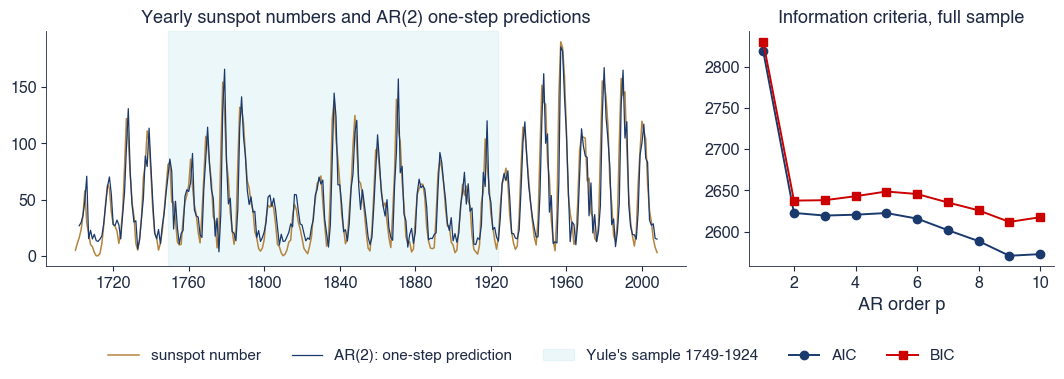

{'phi1': 1.3360517290440952,
 'phi2': -0.6499738960790208,
 'period': 10.57432321660294,
 'mod': 0.8062095857027631,
 'n_yule': 176,
 'aic_p': 9,
 'bic_p': 9,
 'full_phi': [1.3906328567813957, -0.6885729012201299],
 'n': 309,
 'r2': 0.831045940269892}

In [16]:
sun = fig_sunspots(save_it=False)
sun

## Exercises

1. Fit ARMA($p,q$), $p, q \le 2$, to the DAX daily returns (`log_returns('dax')`) and compare the BIC choice with BET.
2. Repeat the Box–Jenkins case for Romanian GDP growth on the sample 2000–2019 (before the pandemic). Does BIC still choose MA(3)?
3. Compute the forecast of the inflation AR(2) 60 months ahead and explain the value it converges to.